 15. This problem involves the Boston data set, which we saw in the lab
 for this chapter. We will now try to predict per capita crime rate
 using the other variables in this data set. In other words, per capita
 crime rate is the response, and the other variables are the predictors.

 (a) For each predictor, fit a simple linear regression model to predict
 the response. Describe your results. In which of the models is
 there a statistically significant association between the predictor
 and the response? Create some plots to back up your assertions.

In [9]:
# Import libraries
from ISLP import load_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats

# Load Boston dataset
boston = load_data("Boston")

# Use CRIM as response, others as predictors
y = boston['crim']
predictors = [col for col in boston.columns if col != 'crim']

# Fit simple linear regression for each predictor
results = []
for pred in predictors:
    X = boston[[pred]].values
    model = LinearRegression().fit(X, y)
    
    # Calculate p-value
    y_pred = model.predict(X)
    n = len(X)
    mse = np.sum((y - y_pred)**2) / (n - 2)
    se = np.sqrt(mse / np.sum((X - X.mean())**2))
    t_stat = model.coef_[0] / se
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))
    
    results.append({
        'Predictor': pred,
        'Coefficient': model.coef_[0],
        'R²': model.score(X, y),
        'p-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

results_df = pd.DataFrame(results).sort_values('p-value')
print(results_df.to_string(index=False))
print(f"\nNumber of significant predictors: {sum(results_df['Significant'] == 'Yes')}/{len(predictors)}")

Predictor  Coefficient       R²      p-value Significant
    indus     0.509776 0.165310 0.000000e+00         Yes
      nox    31.248531 0.177217 0.000000e+00         Yes
      dis    -1.550902 0.144149 0.000000e+00         Yes
      rad     0.617911 0.391257 0.000000e+00         Yes
    lstat     0.548805 0.207591 0.000000e+00         Yes
     medv    -0.363160 0.150780 0.000000e+00         Yes
      tax     0.029742 0.339614 0.000000e+00         Yes
      age     0.107786 0.124421 2.220446e-16         Yes
  ptratio     1.151983 0.084068 2.942935e-11         Yes
       rm    -2.684051 0.048069 6.346703e-07         Yes
       zn    -0.073935 0.040188 5.506472e-06         Yes
     chas    -1.892777 0.003124 2.094345e-01          No

Number of significant predictors: 11/12


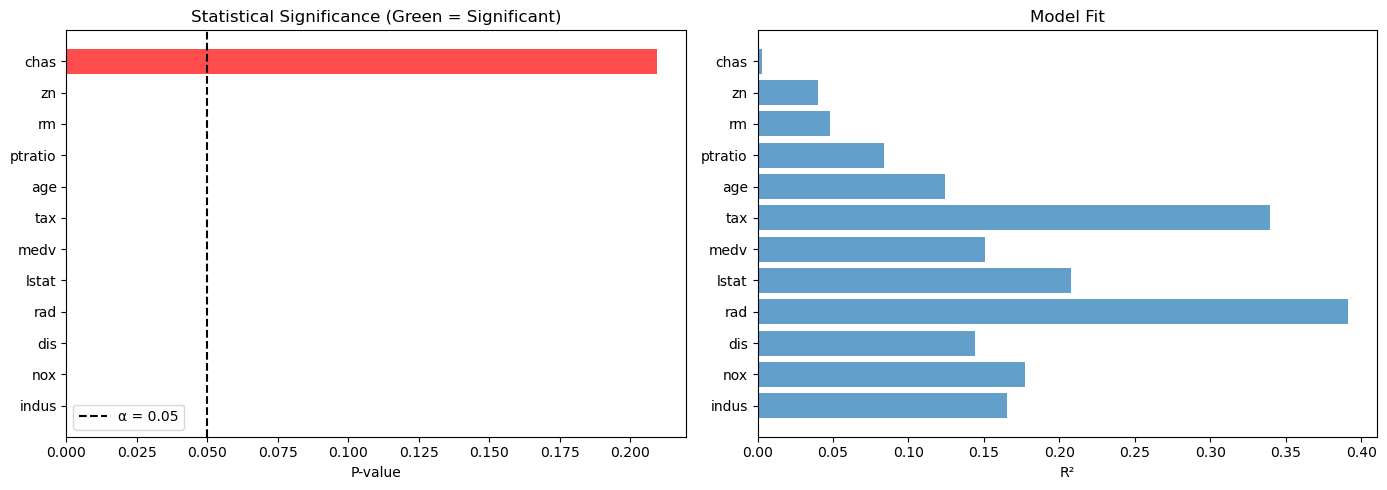

In [10]:
# Visualization 1: P-values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# P-value plot
colors = ['green' if p < 0.05 else 'red' for p in results_df['p-value']]
ax1.barh(results_df['Predictor'], results_df['p-value'], color=colors, alpha=0.7)
ax1.axvline(0.05, color='black', linestyle='--', label='α = 0.05')
ax1.set_xlabel('P-value')
ax1.set_title('Statistical Significance (Green = Significant)')
ax1.legend()

# R² plot
ax2.barh(results_df['Predictor'], results_df['R²'], alpha=0.7)
ax2.set_xlabel('R²')
ax2.set_title('Model Fit')

plt.tight_layout()
plt.show()

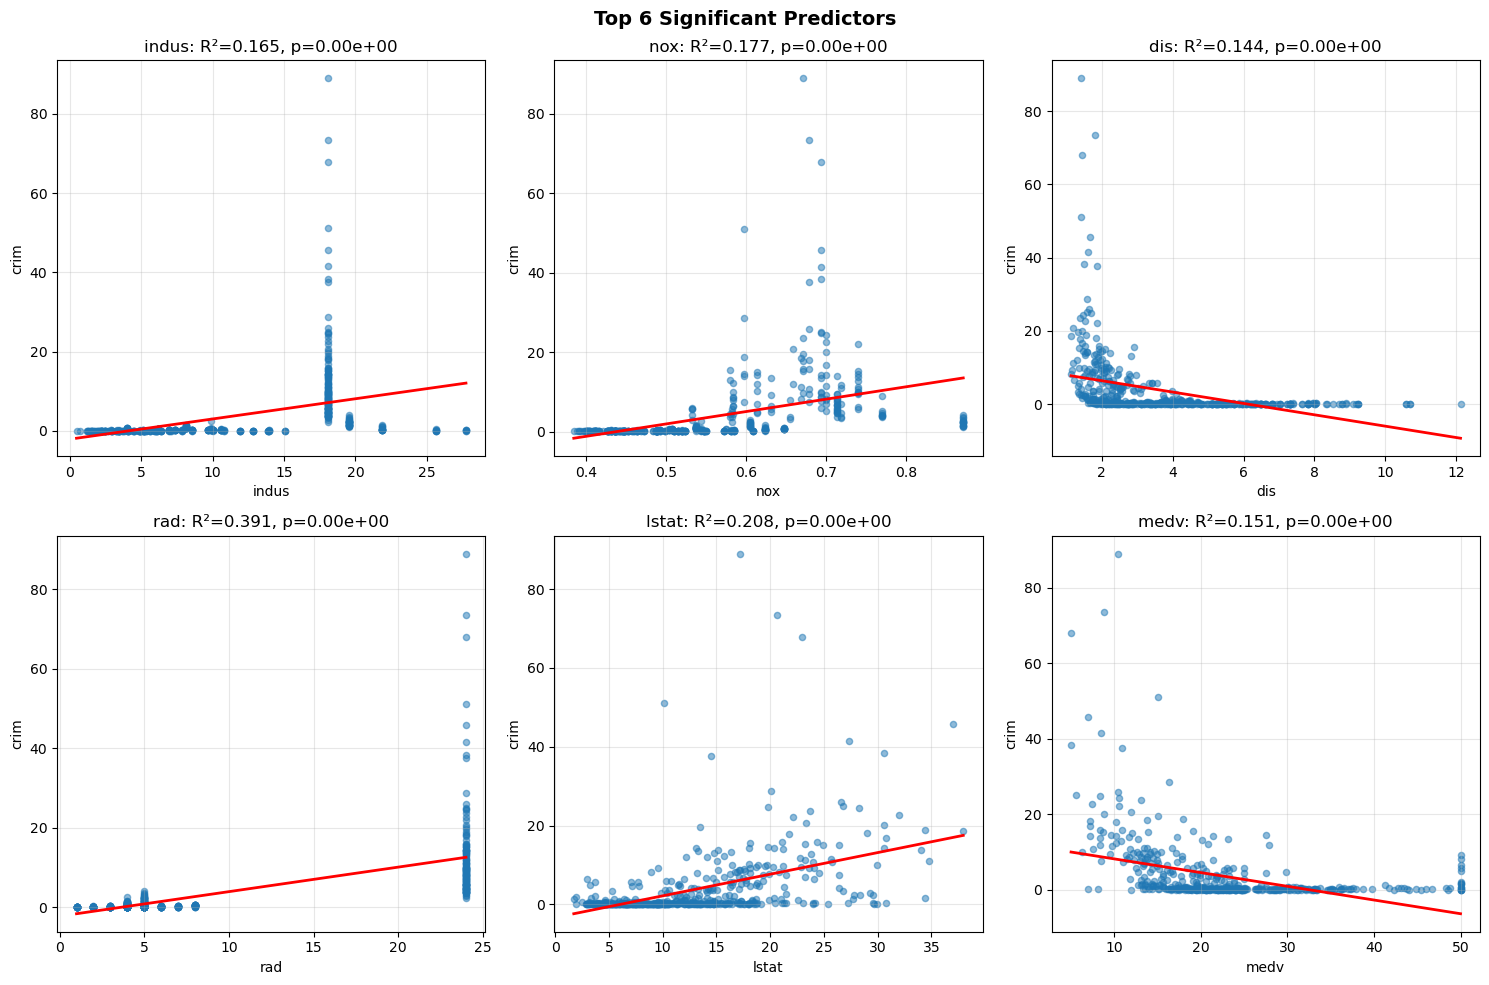

In [11]:
# Visualization 2: Scatter plots for top 6 significant predictors
top6 = results_df[results_df['Significant'] == 'Yes'].head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, row in enumerate(top6.itertuples()):
    X = boston[row.Predictor].values
    model = LinearRegression().fit(X.reshape(-1, 1), y)
    
    axes[idx].scatter(X, y, alpha=0.5, s=20)
    X_line = np.linspace(X.min(), X.max(), 100)
    axes[idx].plot(X_line, model.predict(X_line.reshape(-1, 1)), 'r-', linewidth=2)
    axes[idx].set_xlabel(row.Predictor)
    axes[idx].set_ylabel('crim')
    axes[idx].set_title(f'{row.Predictor}: R²={row._3:.3f}, p={row._4:.2e}')
    axes[idx].grid(alpha=0.3)

plt.suptitle('Top 6 Significant Predictors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

(b) Fit a multiple regression model to predict the response using
 all of the predictors. Describe your results. For which predictors
 can we reject the null hypothesis H0 : βj = 0?

In [12]:
# Fit multiple regression model using all predictors

# Prepare data for multiple regression
X_multi = boston[predictors].values
X_multi_const = sm.add_constant(X_multi)  # Add intercept

# Fit model using statsmodels for detailed statistics
model_multi = sm.OLS(y, X_multi_const).fit()

# Print comprehensive summary
print("=" * 80)
print("MULTIPLE REGRESSION MODEL SUMMARY")
print("=" * 80)
print(model_multi.summary())

print("\n" + "=" * 80)
print("HYPOTHESIS TESTING RESULTS (H0: βj = 0)")
print("=" * 80)

# Extract coefficient information
coef_df = pd.DataFrame({
    'Predictor': ['Intercept'] + predictors,
    'Coefficient': model_multi.params,
    'Std Error': model_multi.bse,
    't-statistic': model_multi.tvalues,
    'p-value': model_multi.pvalues,
    'Reject H0 (α=0.05)': ['Yes' if p < 0.05 else 'No' for p in model_multi.pvalues]
})

# Sort by p-value
coef_df_sorted = coef_df.sort_values('p-value')
print(coef_df_sorted.to_string(index=False))

# Count significant predictors
significant_predictors = coef_df[coef_df['Reject H0 (α=0.05)'] == 'Yes']['Predictor'].tolist()
significant_predictors = [p for p in significant_predictors if p != 'Intercept']

print(f"\n{'-' * 80}")
print(f"Model R²: {model_multi.rsquared:.4f}")
print(f"Adjusted R²: {model_multi.rsquared_adj:.4f}")
print(f"F-statistic: {model_multi.fvalue:.4f} (p-value: {model_multi.f_pvalue:.2e})")
print(f"\nSignificant predictors (can reject H0): {len(significant_predictors)}/{len(predictors)}")
print(f"Predictors: {', '.join(significant_predictors)}")

MULTIPLE REGRESSION MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        00:12:27   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7

 (c) How do your results from (a) compare to your results from (b)?
 Create a plot displaying the univariate regression coefficients
 from (a) on the x-axis, and the multiple regression coefficients
 from (b) on the y-axis. That is, each predictor is displayed as a
 single point in the plot. Its coefficient in a simple linear regres
sion model is shown on the x-axis, and its coefficient estimate
 in the multiple linear regression model is shown on the y-axis.


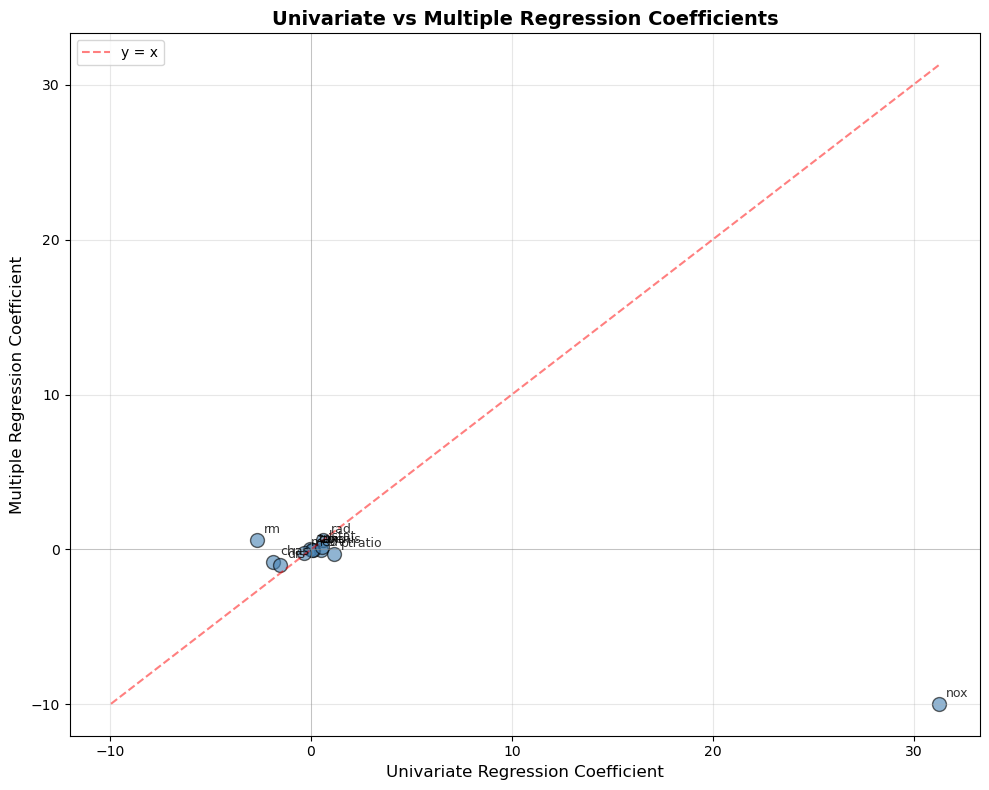

Predictor  Univariate  Multiple  Difference
      nox   31.248531 -9.957587  -41.206118
       rm   -2.684051  0.628911    3.312962
  ptratio    1.151983 -0.304073   -1.456056
     chas   -1.892777 -0.825378    1.067399
    indus    0.509776 -0.058350   -0.568126
      dis   -1.550902 -1.012247    0.538655
    lstat    0.548805  0.138801   -0.410004
     medv   -0.363160 -0.220056    0.143104
       zn   -0.073935  0.045710    0.119645
      age    0.107786 -0.000848   -0.108635
      tax    0.029742 -0.003776   -0.033518
      rad    0.617911  0.612465   -0.005446

Predictors with sign change: 7
Max absolute difference: 41.21 (nox)


In [13]:
# Part (c): Compare univariate vs multiple regression coefficients

# Extract coefficients
univariate_coefs = dict(zip(results_df['Predictor'], results_df['Coefficient']))
multiple_coefs = dict(zip(predictors, model_multi.params[1:]))

# Prepare data for plotting
x_vals = [univariate_coefs[p] for p in predictors]
y_vals = [multiple_coefs[p] for p in predictors]

# Create comparison plot
plt.figure(figsize=(10, 8))
plt.scatter(x_vals, y_vals, s=100, alpha=0.6, c='steelblue', edgecolors='black')

# Add labels
for i, pred in enumerate(predictors):
    plt.annotate(pred, (x_vals[i], y_vals[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8)

# Reference line (y=x)
min_val, max_val = min(min(x_vals), min(y_vals)), max(max(x_vals), max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y = x')

plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
plt.xlabel('Univariate Regression Coefficient', fontsize=12)
plt.ylabel('Multiple Regression Coefficient', fontsize=12)
plt.title('Univariate vs Multiple Regression Coefficients', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
comparison_df = pd.DataFrame({
    'Predictor': predictors,
    'Univariate': [univariate_coefs[p] for p in predictors],
    'Multiple': [multiple_coefs[p] for p in predictors],
    'Difference': [multiple_coefs[p] - univariate_coefs[p] for p in predictors]
})
comparison_df = comparison_df.sort_values('Difference', key=abs, ascending=False)
print(comparison_df.to_string(index=False))

# Key observations
sign_changes = sum((comparison_df['Univariate'] * comparison_df['Multiple']) < 0)
print(f"\nPredictors with sign change: {sign_changes}")
print(f"Max absolute difference: {comparison_df['Difference'].abs().max():.2f} ({comparison_df.loc[comparison_df['Difference'].abs().idxmax(), 'Predictor']})")

 (d) Is there evidence of non-linear association between any of the
 predictors and the response? To answer this question, for each
 predictor X, fit a model of the form
 Y =β0+β1X+β2X2+β3X3+ϵ

In [14]:
# Part (d): Test for non-linear association
# Fit model: Y = β0 + β1*X + β2*X^2 + β3*X^3 + ε

from sklearn.preprocessing import PolynomialFeatures

# Test for non-linearity for each predictor
nonlinear_results = []

for pred in predictors:
    X_poly = boston[[pred]].values
    
    # Fit polynomial model (degree 3)
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly_features = poly.fit_transform(X_poly)
    poly_model = sm.OLS(y, sm.add_constant(X_poly_features)).fit()
    
    # Fit linear model for comparison
    linear_model = sm.OLS(y, sm.add_constant(X_poly)).fit()
    
    # F-test for H0: β2 = β3 = 0
    df_diff = 2
    f_stat = ((linear_model.ssr - poly_model.ssr) / df_diff) / (poly_model.ssr / poly_model.df_resid)
    p_value = 1 - stats.f.cdf(f_stat, df_diff, poly_model.df_resid)
    
    nonlinear_results.append({
        'Predictor': pred,
        'p-value': p_value,
        'Non-linear': 'Yes' if p_value < 0.05 else 'No'
    })

# Display results
result_df = pd.DataFrame(nonlinear_results).sort_values('p-value')
print(result_df.to_string(index=False))
print(f"\nPredictors with non-linear evidence: {sum(result_df['Non-linear'] == 'Yes')}/{len(predictors)}")

Predictor      p-value Non-linear
      nox 1.110223e-16        Yes
      dis 1.110223e-16        Yes
     medv 1.110223e-16        Yes
    indus 8.404388e-14        Yes
      age 4.125056e-07        Yes
      tax 1.144238e-05        Yes
  ptratio 2.541647e-04        Yes
       rm 5.229427e-03        Yes
       zn 8.511995e-03        Yes
      rad 2.607832e-02        Yes
    lstat 3.698322e-02        Yes
     chas 1.000000e+00         No

Predictors with non-linear evidence: 11/12


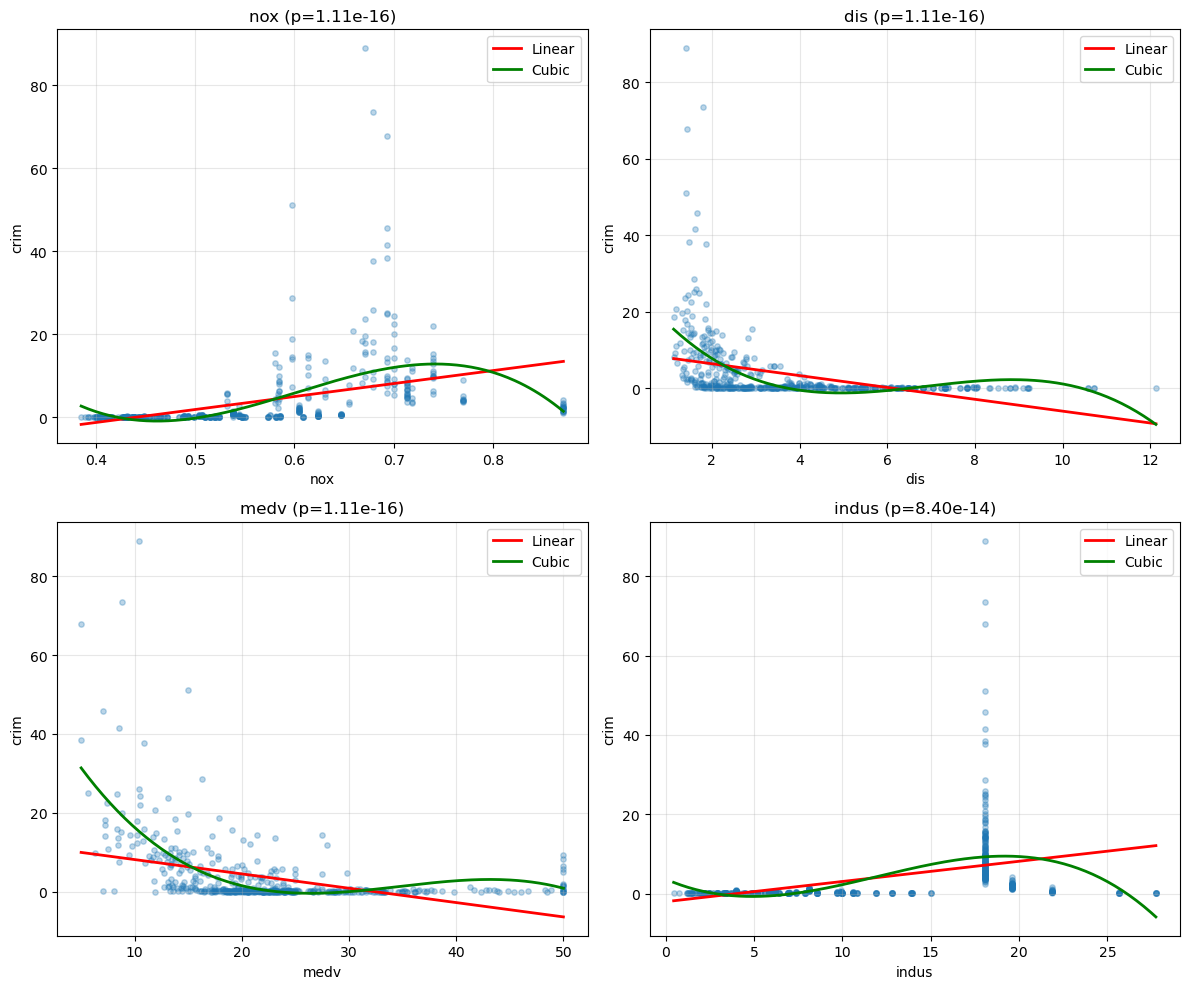

In [15]:
# Plot top 4 non-linear predictors
top4 = result_df[result_df['Non-linear'] == 'Yes'].head(4)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (_, row) in enumerate(top4.iterrows()):
    X_plot = boston[row['Predictor']].values.reshape(-1, 1)
    
    # Linear fit
    linear_model = LinearRegression().fit(X_plot, y)
    
    # Polynomial fit
    poly = PolynomialFeatures(degree=3)
    X_poly = poly.fit_transform(X_plot)
    poly_model = LinearRegression().fit(X_poly, y)
    
    # Plot
    X_range = np.linspace(X_plot.min(), X_plot.max(), 200).reshape(-1, 1)
    axes[idx].scatter(X_plot, y, alpha=0.3, s=15)
    axes[idx].plot(X_range, linear_model.predict(X_range), 'r-', label='Linear', linewidth=2)
    axes[idx].plot(X_range, poly_model.predict(poly.fit_transform(X_range)), 'g-', label='Cubic', linewidth=2)
    axes[idx].set_xlabel(row['Predictor'])
    axes[idx].set_ylabel('crim')
    axes[idx].set_title(f"{row['Predictor']} (p={row['p-value']:.2e})")
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()